# Credit Card Fraud Detection
Use a variety of methods to detect credit card fraud

In [1]:
!pip install xgboost imblearn

In [2]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

#from imblearn.over_sampling import SMOTE
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

## Data loading and preprocessing
### Load and display data
Specifying target column for easier use down the line

Can change said column later if wanted

In [3]:
# load data
target_value = "Class"
data = pd.read_csv("creditcard.csv")
y_vals = data[target_value]
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Missing values
The data does contain missing values

Using mean imputation to fill values, could use something like knn or drop rows/columns instead if wanted

Dropping target column here as well

In [4]:
has_nan = data.isnull().values.any() # any bad vals?
if has_nan:
    print("Data contains NaN values")
    data = data.fillna(data.mean())
else:
    print("Data does not contain NaN values")

Data does not contain NaN values


### Visualize class imbalance

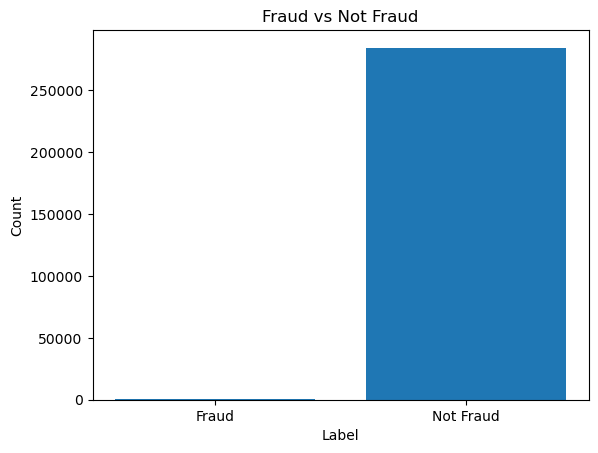

Fraud: 492 Not: 284315


In [5]:
y_vals
plt.bar(["Fraud", "Not Fraud"], [sum(y_vals), len(y_vals)-sum(y_vals)])
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Fraud vs Not Fraud")
plt.show()
print("Fraud:", sum(y_vals), "Not:", len(y_vals)-sum(y_vals))

## Spliting, imbalance, and scaling data

### Handle imbalance with SMOTE

In [6]:
# X, y = SMOTE(data.drop(target_value, axis=1), y_vals)
X = data.drop(target_value, axis=1)
y = y_vals

### Split data with 80/20 split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42)

### Scale data

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Models
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost
- Decision Tree

### Random Forest

In [9]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

### AdaBoost

In [10]:
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

### Gradient Boosting

In [11]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

### XGBoost

In [12]:
xg_model = xgb.XGBClassifier(n_estimators=100, random_state=42)
xg_model.fit(X_train, y_train)
y_pred_xg = xg_model.predict(X_test)

### Decision Tree

In [13]:
dt_model = DecisionTreeClassifier(max_depth=10)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

## Results

### Accuracy

In [14]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xg))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Random Forest Accuracy: 0.9995611109160493
AdaBoost Accuracy: 0.9993504441557529
Gradient Boosting Accuracy: 0.9989466661985184
XGBoost Accuracy: 0.9995611109160493
Decision Tree Accuracy: 0.999420666409185


### Precision

In [15]:
print("Random Forest Precision:", precision_score(y_test, y_pred_rf))
print("AdaBoost Precision:", precision_score(y_test, y_pred_ada))
print("Gradient Boosting Precision:", precision_score(y_test, y_pred_gb))
print("XGBoost Precision:", precision_score(y_test, y_pred_xg))
print("Decision Tree Precision:", precision_score(y_test, y_pred_dt))

Random Forest Precision: 0.974025974025974
AdaBoost Precision: 0.8674698795180723
Gradient Boosting Precision: 0.7375
XGBoost Precision: 0.9620253164556962
Decision Tree Precision: 0.8735632183908046


### Recall

In [16]:
print("Random Forest Recall:", recall_score(y_test, y_pred_rf))
print("AdaBoost Recall:", recall_score(y_test, y_pred_ada))
print("Gradient Boosting Recall:", recall_score(y_test, y_pred_gb))
print("XGBoost Recall:", recall_score(y_test, y_pred_xg))
print("Decision Tree Recall:", recall_score(y_test, y_pred_dt))

Random Forest Recall: 0.7653061224489796
AdaBoost Recall: 0.7346938775510204
Gradient Boosting Recall: 0.6020408163265306
XGBoost Recall: 0.7755102040816326
Decision Tree Recall: 0.7755102040816326


### F1 Score

In [17]:
print("Random Forest F1:", f1_score(y_test, y_pred_rf))
print("AdaBoost F1:", f1_score(y_test, y_pred_ada))
print("Gradient Boosting F1:", f1_score(y_test, y_pred_gb))
print("XGBoost F1:", f1_score(y_test, y_pred_xg))
print("Decision Tree F1:", f1_score(y_test, y_pred_dt))

Random Forest F1: 0.8571428571428571
AdaBoost F1: 0.7955801104972375
Gradient Boosting F1: 0.6629213483146067
XGBoost F1: 0.8587570621468926
Decision Tree F1: 0.8216216216216217


### ROC Curves and AUC

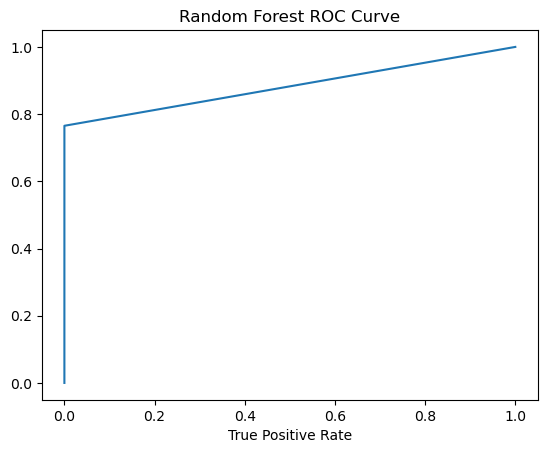

Random Forest AUC: 0.8826354754056941


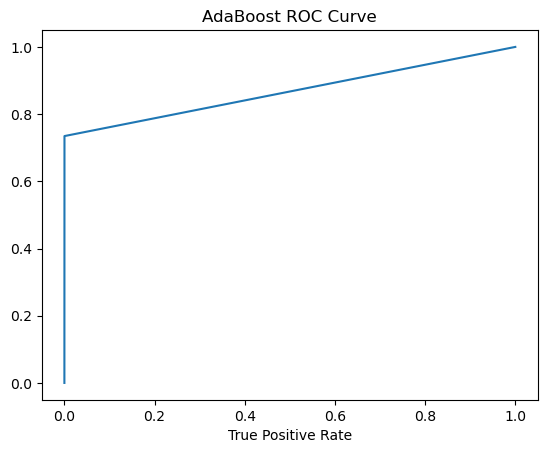

AdaBoost AUC: 0.8672502167721337


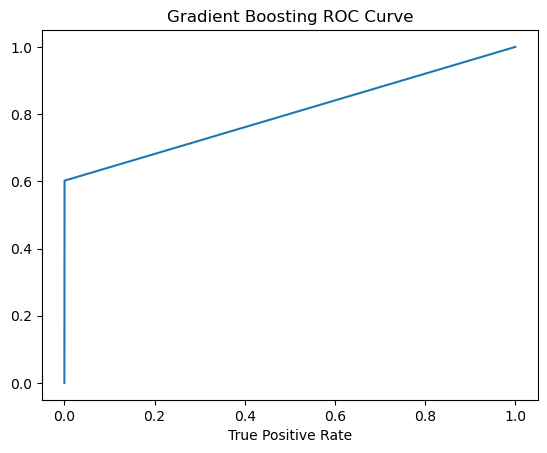

Gradient Boosting AUC: 0.8008357570659101


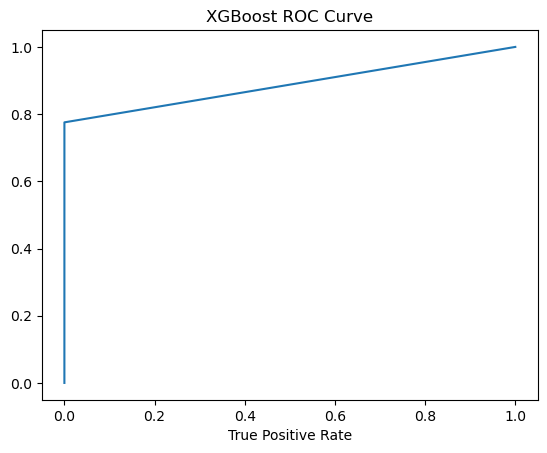

XGBoost AUC: 0.8877287233126226


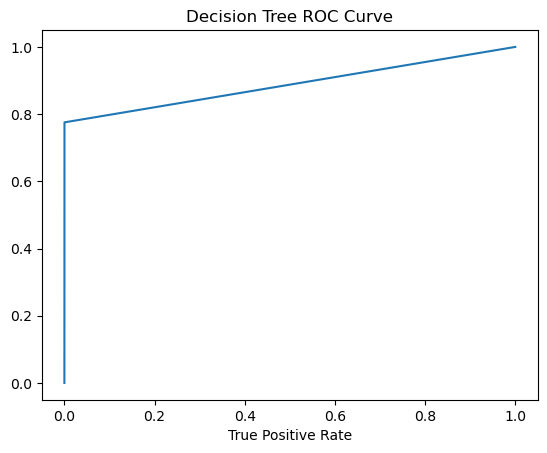

Decision Tree AUC: 0.8876583800374398


In [18]:
fpr, tpr, _ = roc_curve(y_test, y_pred_rf)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.xlabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.show()
print("Random Forest AUC:", roc_auc_score(y_test, y_pred_rf))

fpr, tpr, _ = roc_curve(y_test, y_pred_ada)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.xlabel("True Positive Rate")
plt.title("AdaBoost ROC Curve")
plt.show()
print("AdaBoost AUC:", roc_auc_score(y_test, y_pred_ada))

fpr, tpr, _ = roc_curve(y_test, y_pred_gb)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.xlabel("True Positive Rate")
plt.title("Gradient Boosting ROC Curve")
plt.show()
print("Gradient Boosting AUC:", roc_auc_score(y_test, y_pred_gb))

fpr, tpr, _ = roc_curve(y_test, y_pred_xg)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.xlabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.show()
print("XGBoost AUC:", roc_auc_score(y_test, y_pred_xg))

fpr, tpr, _ = roc_curve(y_test, y_pred_dt)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.xlabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.show()
print("Decision Tree AUC:", roc_auc_score(y_test, y_pred_dt))
